In [2]:
import ml_library as ml
import pandas as pd



In [ ]:
#type: ignore

# Do anything that is specific to this dataset
def nba_specific(df) -> pd.DataFrame:
    try:
        df = df.drop(columns=['Unnamed: 0'])
        df['position'] = df['position'].replace('PG-SG', 'PG')
        df['position'] = df['position'].replace('SM-PF', 'SF')
    except KeyError:
        pass
    return df


MISSING DATA DIAGNOSTIC REPORT

Total rows: 467
Total columns: 29
Columns with missing data: 5
Rows with any missing data: 34
Total missing values: 42
Overall missing percentage: 0.31%

MISSING DATA BY COLUMN
Column  Missing_Count  Missing_Percent Data_Type
   FT%             23         4.925054   float64
   3P%             13         2.783726   float64
   2P%              4         0.856531   float64
   FG%              1         0.214133   float64
  eFG%              1         0.214133   float64


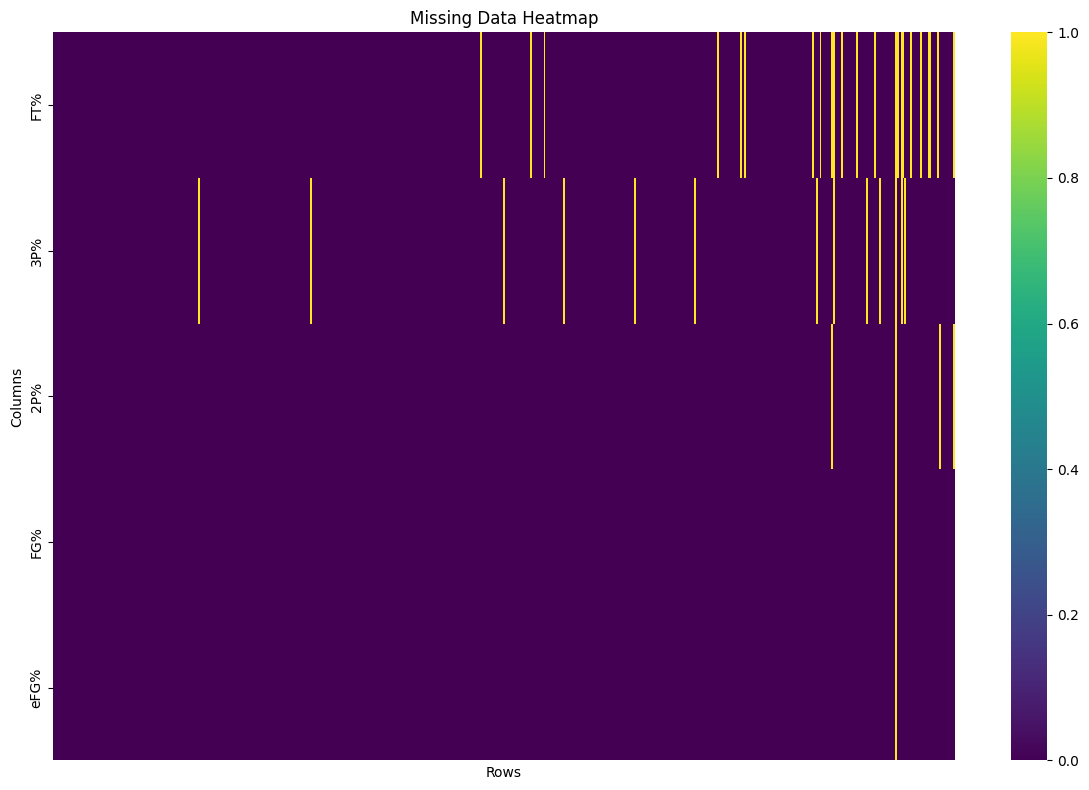


MISSING DATA MECHANISM ANALYSIS

⚠ HIGH CORRELATIONS between missing data patterns detected:
   This suggests data may be MAR or MNAR (not MCAR)

   FT% ↔ 2P%: 0.301
   2P% ↔ FG%: 0.498
   2P% ↔ eFG%: 0.498
   FG% ↔ eFG%: 1.000


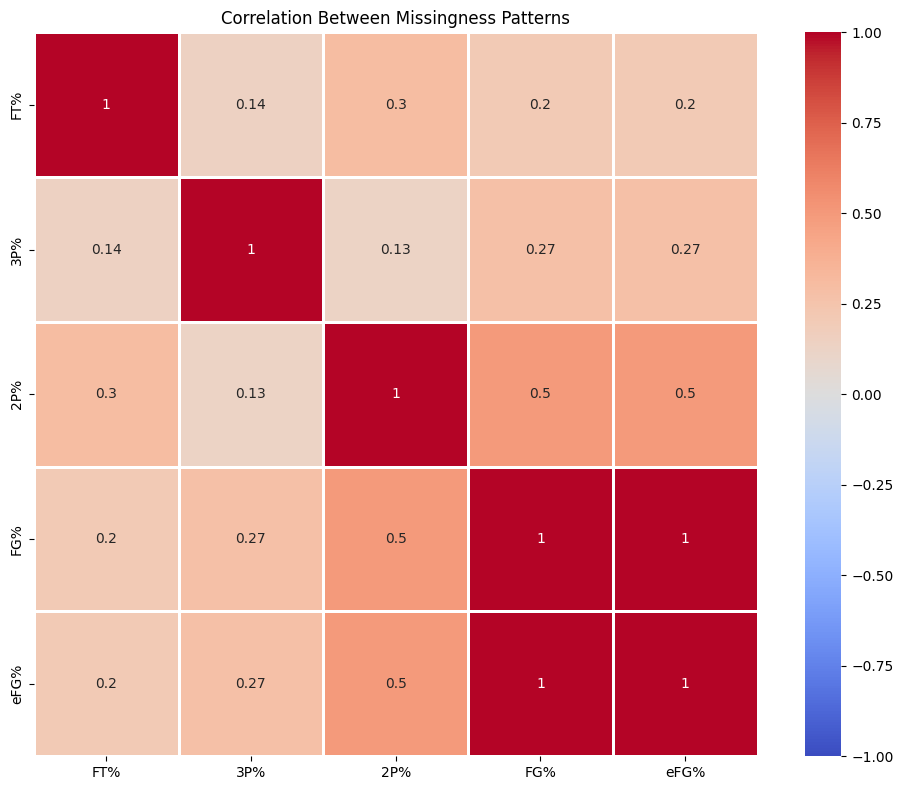


MISSING DATA HANDLING

Initial shape: (467, 29)
Initial missing values: 42

✓ No columns exceed 90% missing threshold
✓ No rows exceed 90% missing threshold

→ 42 missing values remaining across 5 columns
→ Applying 'mean' imputation strategy...
   FG%: filled with mean = 0.47
   3P%: filled with mean = 0.33
   2P%: filled with mean = 0.53
   eFG%: filled with mean = 0.53
   FT%: filled with mean = 0.75

✓ Imputation complete
   Missing values after imputation: 42

Final shape: (467, 29)


c:\Users\GeorgeColinRamsay\Documents\GitHub\IS-455\ML-Pipeline-Kit\ml_library.py:427: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(fill_value, inplace=True)


,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,0.493,...,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4
1,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,0.408,...,0.681,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4
2,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,0.436,...,0.656,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9
3,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,0.500,...,0.768,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9
4,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,0.560,...,0.919,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1


In [6]:
df = pd.read_csv('C:\\Users\\GeorgeColinRamsay\\Documents\\GitHub\\IS-455\\ML-Pipeline-Kit\\nba_salaries.csv')

df = ml.drop_columns(df)
df = nba_specific(df)

diagnostics = ml.missing_data_diagnostics(df, show_plots=True)
df = ml.handle_missing_data(df, drop_threshold=0.9, impute_strategy='mean', verbose=True)

df = ml.bin_categories(df)

df.head()